<div class="alert alert-block alert-info">
    <h1>Análisis de Series Temporales</h1>
    <h3>Clase 3</h3>
    <h3>Ejercicio 3</h3>
        <p>Docente: Rodrigo Del Rosso<p>
        <p>Asistente: Sebastián Calcagno<p>
</div>

Aca analizamos la cantidad diaria de visitantes de cuatro restaurantes y buscamos pronosticar el total de visitas.

como siempre primero:
Limpiamos y grafica los datos. Analiza tendencia, estacionalidad, FAC, FACP y estacionariedad con ADF. Detecta una estacionalidad semanal de 7 días.
Divide los datos en entrenamiento y prueba.

Despues seguimos comparando modelos SARIMA:
uno solo estacional, otro que agrega una parte AR(2) ,
modelos SARIMAX con variables externas, como feriados.

Despues evalua residuos con Ljung-Box y los pronósticos con MSE y RMSE.
Lo más importante

Se muestra que no alcanza con encontrar un modelo con buen ajuste, tb hay que comprobar que sus residuos sean ruido blanco y evaluar su desempeño sobre datos que el modelo no utilizo para entrenarse

El agregado de la variable holiday es interesante porque los feriados son conocidos de antemano y pueden afectar la cantidad de clientes.

Instalamos versiones de libererias para poder trabajar sin problemas.

In [ ]:
!pip install numpy==1.26.4 pandas==2.2.2 statsmodels==0.14.4 pmdarima==2.0.4
!pip install scipy==1.13.1

Importamos librerias

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.tsa.api as smt
%matplotlib inline

from pylab import rcParams
rcParams['figure.figsize'] = (18,6)

import warnings
warnings.filterwarnings(action='ignore',category=DeprecationWarning)
warnings.filterwarnings(action='ignore',category=FutureWarning)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
from pmdarima import auto_arima

In [ ]:
import statsmodels.api as sm

Leemos los datos

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/sebcalcagno/AnalisisSeriesTemporales/refs/heads/main/RestaurantVisitors.csv',index_col='date',parse_dates=True)
print(df)

              weekday  holiday    holiday_name  rest1  rest2  rest3  rest4  \
date                                                                         
2016-01-01     Friday        1  New Year's Day   65.0   25.0   67.0  139.0   
2016-01-02   Saturday        0              na   24.0   39.0   43.0   85.0   
2016-01-03     Sunday        0              na   24.0   31.0   66.0   81.0   
2016-01-04     Monday        0              na   23.0   18.0   32.0   32.0   
2016-01-05    Tuesday        0              na    2.0   15.0   38.0   43.0   
...               ...      ...             ...    ...    ...    ...    ...   
2017-05-27   Saturday        0              na    NaN    NaN    NaN    NaN   
2017-05-28     Sunday        0              na    NaN    NaN    NaN    NaN   
2017-05-29     Monday        1    Memorial Day    NaN    NaN    NaN    NaN   
2017-05-30    Tuesday        0              na    NaN    NaN    NaN    NaN   
2017-05-31  Wednesday        0              na    NaN    NaN    

In [ ]:
df.index.freq = 'D'

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 517 entries, 2016-01-01 to 2017-05-31
Freq: D
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   weekday       517 non-null    object 
 1   holiday       517 non-null    int64  
 2   holiday_name  517 non-null    object 
 3   rest1         478 non-null    float64
 4   rest2         478 non-null    float64
 5   rest3         478 non-null    float64
 6   rest4         478 non-null    float64
 7   total         478 non-null    float64
dtypes: float64(5), int64(1), object(2)
memory usage: 36.4+ KB


In [ ]:
df.isnull().sum()

,0
weekday,0
holiday,0
holiday_name,0
rest1,39
rest2,39
rest3,39
rest4,39
total,39


In [ ]:
df1 = df.dropna()
df1.tail()

,weekday,holiday,holiday_name,rest1,rest2,rest3,rest4,total
date,,,,,,,,
2017-04-18,Tuesday,0,na,30.0,30.0,13.0,18.0,91.0
2017-04-19,Wednesday,0,na,20.0,11.0,30.0,18.0,79.0
2017-04-20,Thursday,0,na,22.0,3.0,19.0,46.0,90.0
2017-04-21,Friday,0,na,38.0,53.0,36.0,38.0,165.0
2017-04-22,Saturday,0,na,97.0,20.0,50.0,59.0,226.0


In [ ]:
cols = ['rest1','rest2','rest3','rest4', "total"]

for col in cols:
    df1[col] = df1[col].astype(int)
df1.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 478 entries, 2016-01-01 to 2017-04-22
Freq: D
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   weekday       478 non-null    object
 1   holiday       478 non-null    int64 
 2   holiday_name  478 non-null    object
 3   rest1         478 non-null    int64 
 4   rest2         478 non-null    int64 
 5   rest3         478 non-null    int64 
 6   rest4         478 non-null    int64 
 7   total         478 non-null    int64 
dtypes: int64(6), object(2)
memory usage: 33.6+ KB


/tmp/ipykernel_2760/4264777700.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1[col] = df1[col].astype(int)
/tmp/ipykernel_2760/4264777700.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1[col] = df1[col].astype(int)
/tmp/ipykernel_2760/4264777700.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/in

In [ ]:
print(df1)

              weekday  holiday    holiday_name  rest1  rest2  rest3  rest4  \
date                                                                         
2016-01-01     Friday        1  New Year's Day     65     25     67    139   
2016-01-02   Saturday        0              na     24     39     43     85   
2016-01-03     Sunday        0              na     24     31     66     81   
2016-01-04     Monday        0              na     23     18     32     32   
2016-01-05    Tuesday        0              na      2     15     38     43   
...               ...      ...             ...    ...    ...    ...    ...   
2017-04-18    Tuesday        0              na     30     30     13     18   
2017-04-19  Wednesday        0              na     20     11     30     18   
2017-04-20   Thursday        0              na     22      3     19     46   
2017-04-21     Friday        0              na     38     53     36     38   
2017-04-22   Saturday        0              na     97     20    

In [ ]:
df1["mean"] = df1[['rest1', 'rest2', 'rest3','rest4',]].mean(axis = 1)
print(df1)

              weekday  holiday    holiday_name  rest1  rest2  rest3  rest4  \
date                                                                         
2016-01-01     Friday        1  New Year's Day     65     25     67    139   
2016-01-02   Saturday        0              na     24     39     43     85   
2016-01-03     Sunday        0              na     24     31     66     81   
2016-01-04     Monday        0              na     23     18     32     32   
2016-01-05    Tuesday        0              na      2     15     38     43   
...               ...      ...             ...    ...    ...    ...    ...   
2017-04-18    Tuesday        0              na     30     30     13     18   
2017-04-19  Wednesday        0              na     20     11     30     18   
2017-04-20   Thursday        0              na     22      3     19     46   
2017-04-21     Friday        0              na     38     53     36     38   
2017-04-22   Saturday        0              na     97     20    

/tmp/ipykernel_2760/3406057565.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["mean"] = df1[['rest1', 'rest2', 'rest3','rest4',]].mean(axis = 1)


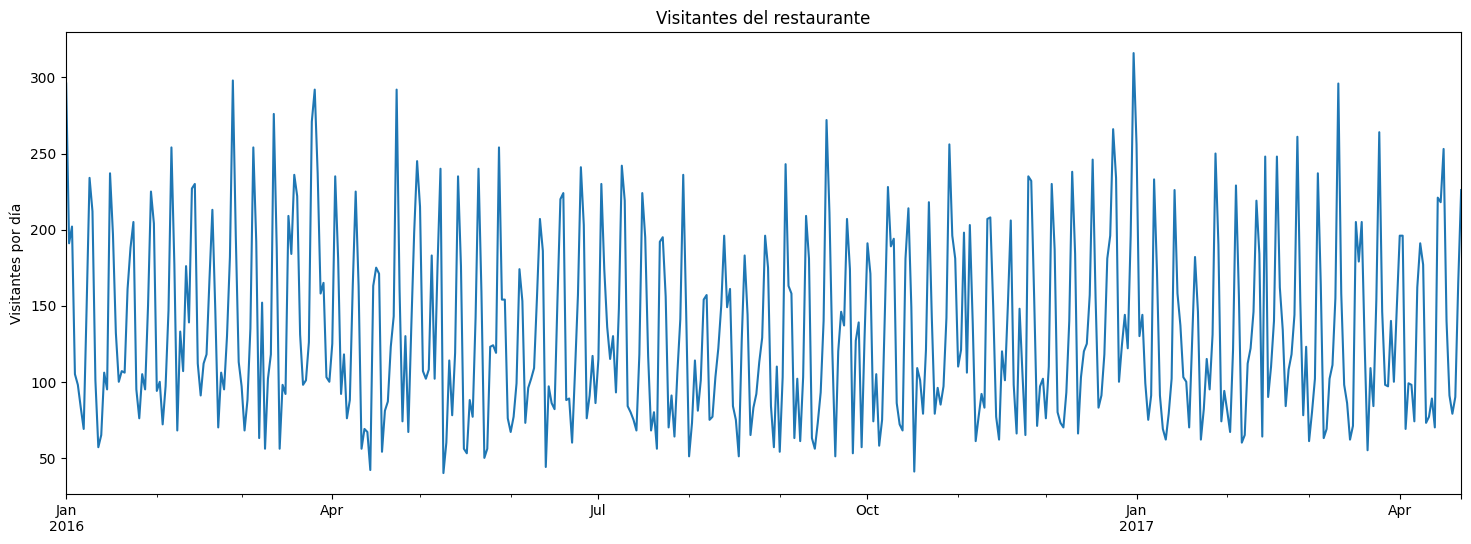

In [ ]:
title = 'Visitantes del restaurante'
xlabel = ''
ylabel = 'Visitantes por día'

ax = df1['total'].plot(title=title)
ax.autoscale(axis='x',tight=True)
ax.set(xlabel=xlabel,ylabel=ylabel);

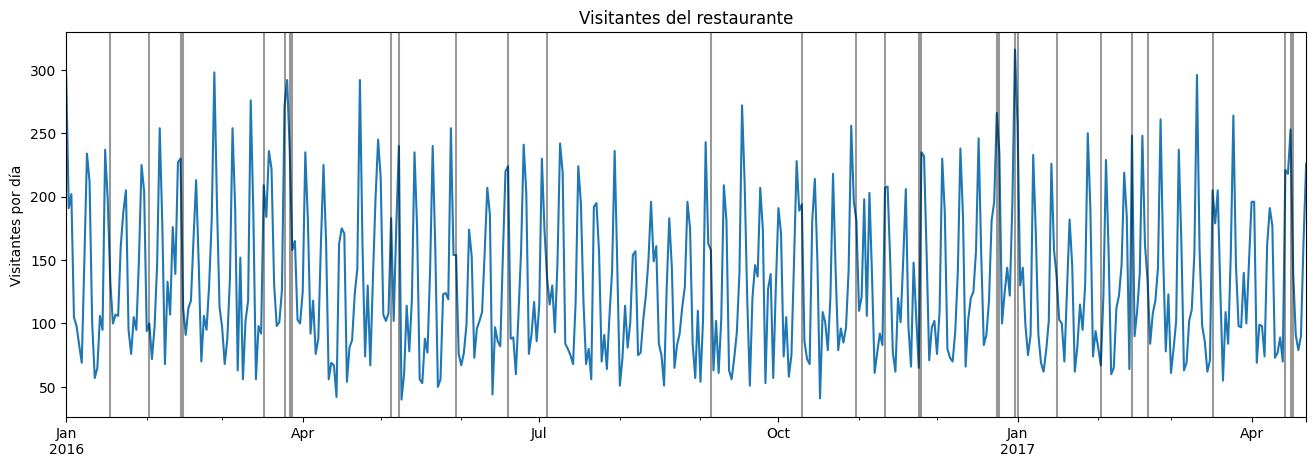

In [ ]:
title='Visitantes del restaurante'
ylabel='Visitantes por día'
xlabel=''

ax = df1['total'].plot(figsize=(16,5),title=title)
ax.autoscale(axis='x',tight=True)
ax.set(xlabel=xlabel, ylabel=ylabel)
for i in df1[df1['holiday']==1].index:
    ax.axvline(x=i,color='k',alpha=0.4)

In [ ]:
df1.columns

Index(['weekday', 'holiday', 'holiday_name', 'rest1', 'rest2', 'rest3',
       'rest4', 'total', 'mean'],
      dtype='object')

/tmp/ipykernel_831/959827538.py:5: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(df1, x = df1.index, y = 'rest1',  label = "Restaurante 1", linestyle="--", linewidth=2, ax = axes[0,1], palette = "Set2")
/tmp/ipykernel_831/959827538.py:8: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(df1, x = df1.index, y = 'rest2',  label = "Restaurante 2", linestyle="--", linewidth=2, ax = axes[1,0], palette = "Set2")
/tmp/ipykernel_831/959827538.py:11: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(df1, x = df1.index, y = 'rest3',  label = "Restaurante 3", linestyle="--", linewidth=2, ax = axes[1,1], palette = "Set2")
/tmp/ipykernel_831/959827538.py:14: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(df1, x = df1.index, y = 'rest4',  label = "Restaurante 4", linestyle="--", linewidth=2, ax = axes[2,0], palette = "Set2")
/t

<Axes: xlabel='date', ylabel='mean'>

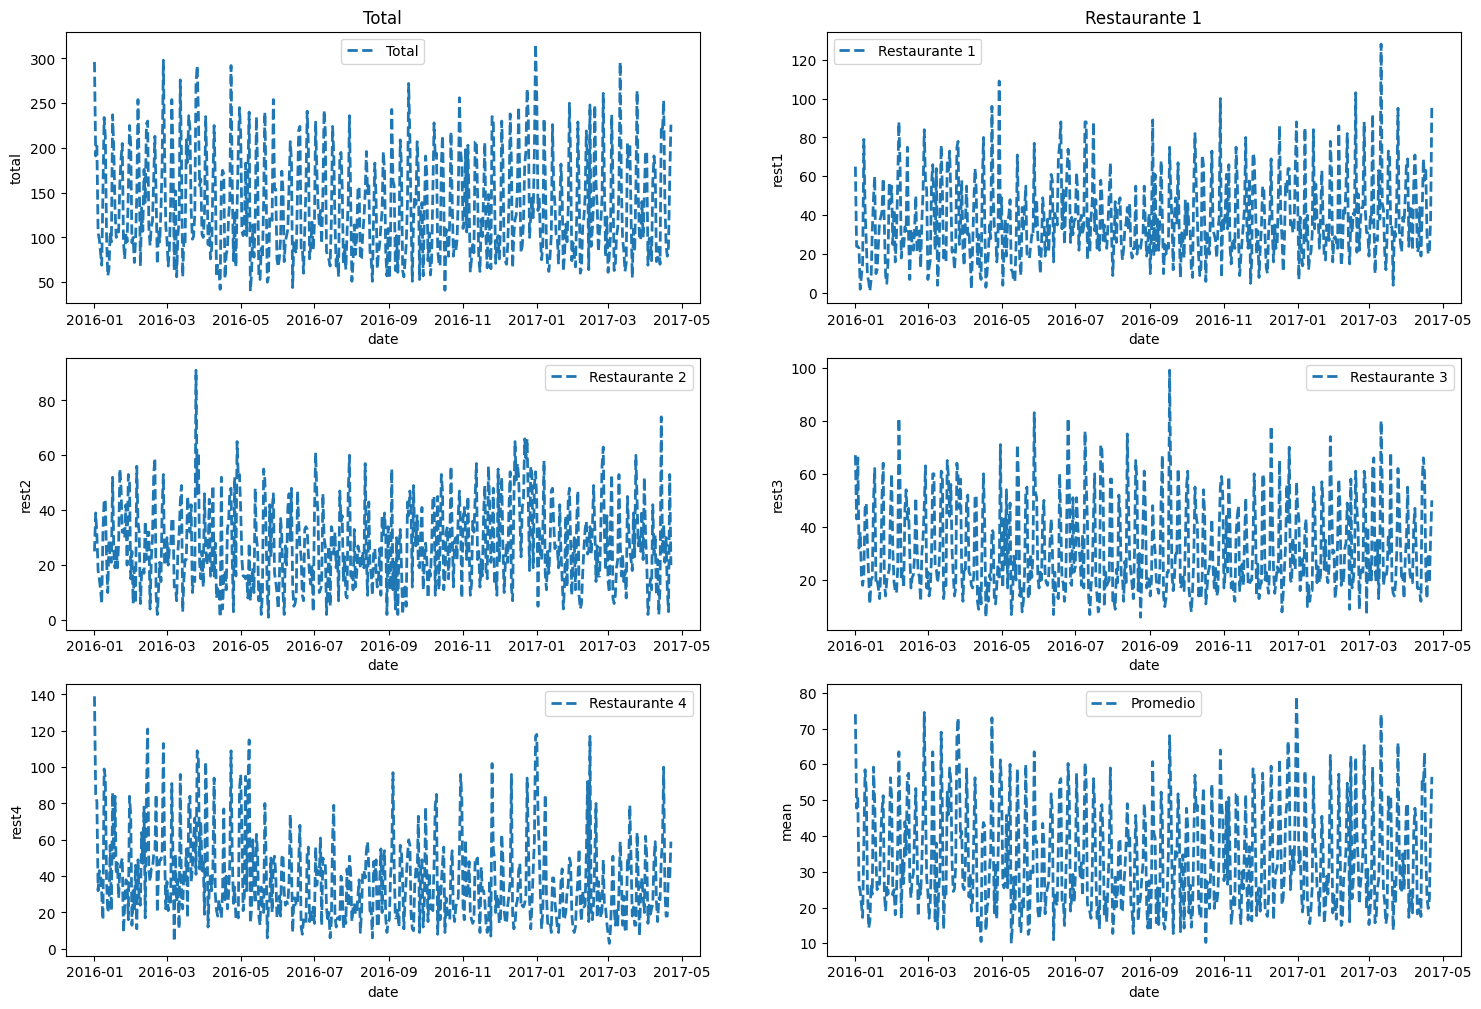

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(18, 12))
sns.lineplot(df1, x = df1.index, y = 'total',  label = "Total", linestyle="--", linewidth=2, ax = axes[0,0])
axes[0,0].set_title("Total")

sns.lineplot(df1, x = df1.index, y = 'rest1',  label = "Restaurante 1", linestyle="--", linewidth=2, ax = axes[0,1], palette = "Set2")
axes[0,1].set_title("Restaurante 1")

sns.lineplot(df1, x = df1.index, y = 'rest2',  label = "Restaurante 2", linestyle="--", linewidth=2, ax = axes[1,0], palette = "Set2")
#axes[1,0].set_title("Restaurante 2")

sns.lineplot(df1, x = df1.index, y = 'rest3',  label = "Restaurante 3", linestyle="--", linewidth=2, ax = axes[1,1], palette = "Set2")
#axes[1,1].set_title("Restaurante 3")

sns.lineplot(df1, x = df1.index, y = 'rest4',  label = "Restaurante 4", linestyle="--", linewidth=2, ax = axes[2,0], palette = "Set2")

sns.lineplot(df1, x = df1.index, y = 'mean',  label = "Promedio", linestyle="--", linewidth=2, ax = axes[2,1], palette = "Set2")
#axes[2,0].set_title("Restaurante 4")

<Axes: xlabel='date', ylabel='total'>

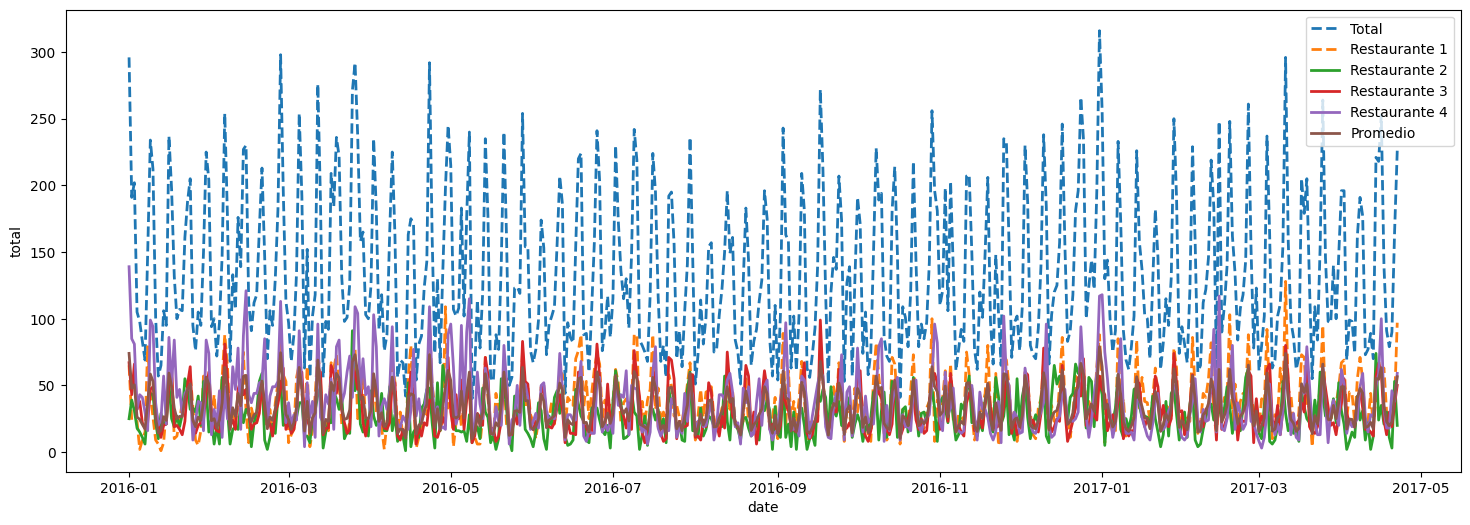

In [ ]:
sns.lineplot(df1, x = df1.index, y = 'total',  label = "Total", linestyle="--", linewidth=2, )
sns.lineplot(df1, x = df1.index, y = 'rest1',  label = "Restaurante 1", linestyle="--", linewidth=2,)
sns.lineplot(df1, x = df1.index, y = 'rest2',  label = "Restaurante 2",  linewidth=2,)
sns.lineplot(df1, x = df1.index, y = 'rest3',  label = "Restaurante 3",  linewidth=2,)
sns.lineplot(df1, x = df1.index, y = 'rest4',  label = "Restaurante 4",  linewidth=2,)
sns.lineplot(df1, x = df1.index, y = 'mean',  label = "Promedio",  linewidth=2,)

<Axes: xlabel='date', ylabel='rest4'>

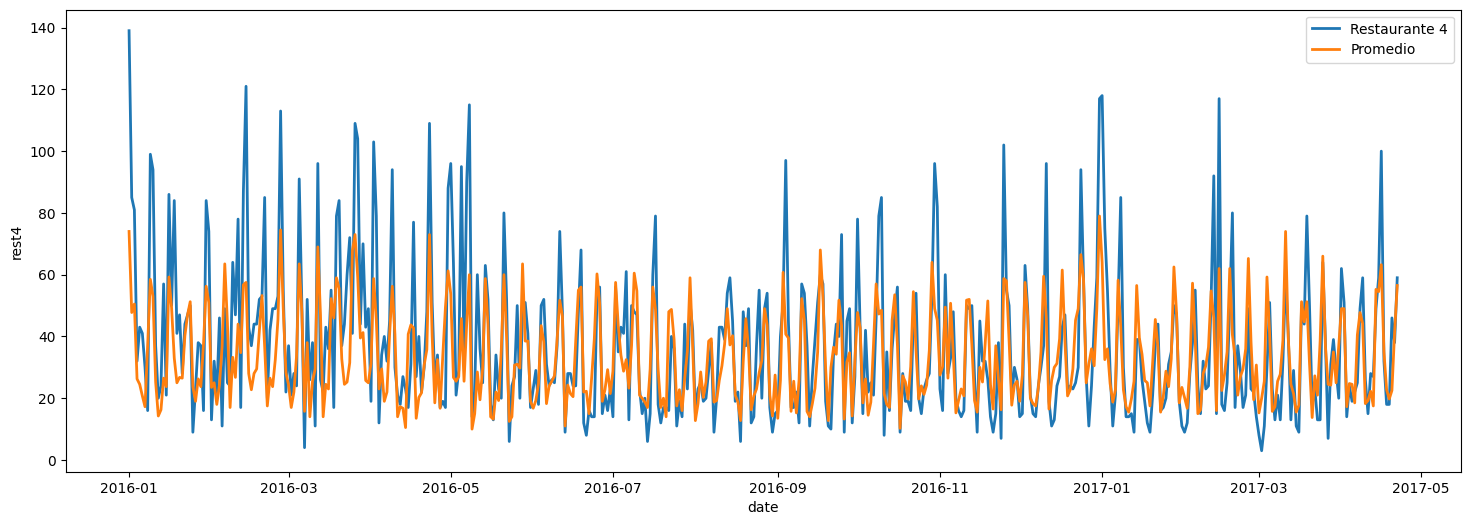

In [ ]:
sns.lineplot(df1, x = df1.index, y = 'rest4',  label = "Restaurante 4",  linewidth=2,)
sns.lineplot(df1, x = df1.index, y = 'mean',  label = "Promedio",  linewidth=2,)

In [ ]:
result = seasonal_decompose(df1['total'], model="additive")

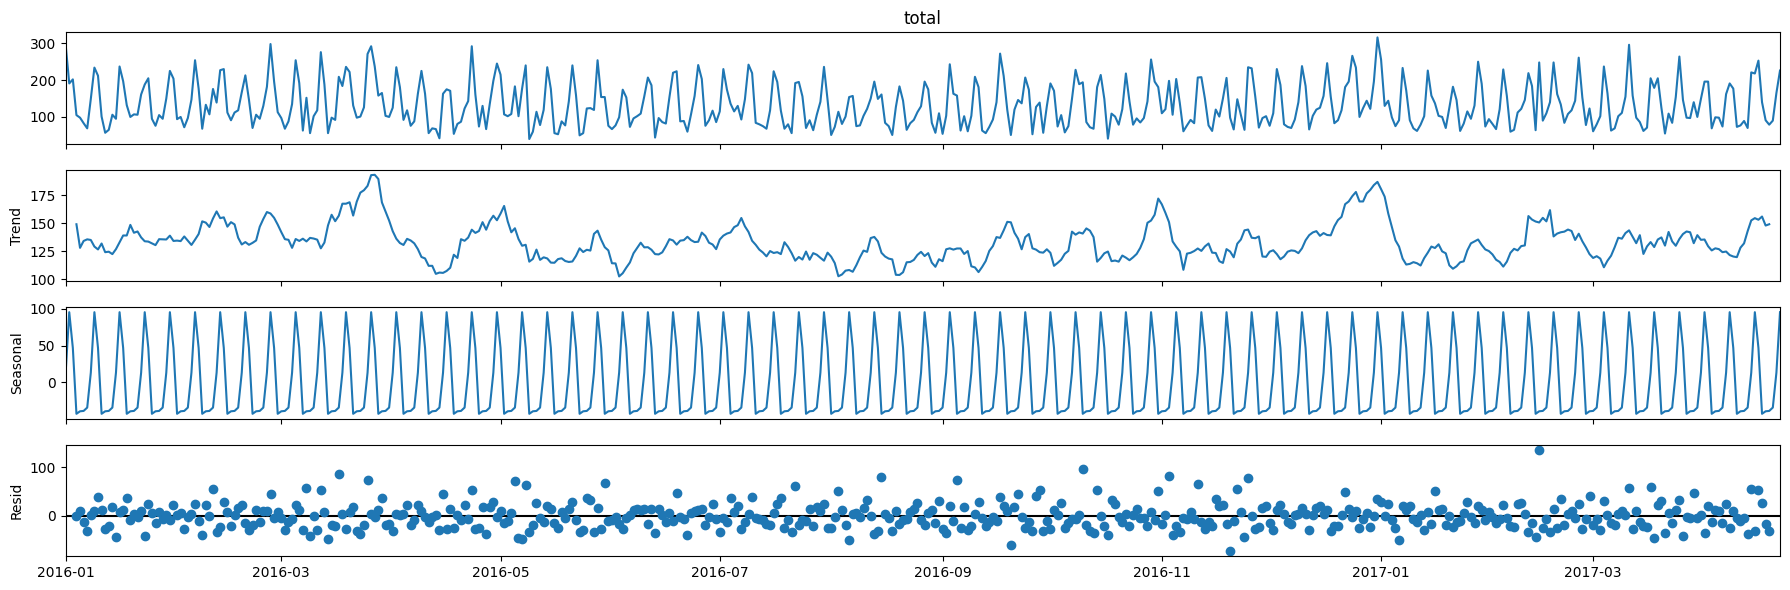

In [ ]:
result.plot();

In [ ]:
from statsmodels.tsa.stattools import adfuller

In [ ]:
import statsmodels.tsa.stattools as tsa

In [ ]:
# No incluye termino independiente ni lineal (None)

# Aca corremos el test sin incluir constante ni tendencia.


tsa.adfuller(df1['total'], maxlag=None, regression='n', autolag='AIC', store=False, regresults=False)

(-0.2949629235496231,
 0.5780093932960101,
 15,
 462,
 {'1%': -2.570596386686906,
  '5%': -1.9415968339131058,
  '10%': -1.616257566291707},
 4621.759525363998)

In [ ]:
# Incluya termino independiente pero no incluye termino lineal (Drift)
tsa.adfuller(df1['total'], maxlag=None, regression='c', autolag='AIC', store=False, regresults=False)

# Aca se corre la versión del test Dickey–Fuller Aumentado que incluye un termino constante y permite evaluar si la serie es estacionaria alrededor de un nivel fijo.
# Es una de las variantes + utilizadas del ADF en series economicas y de demanda.


(-5.592496972543471,
 1.3193770946941756e-06,
 18,
 459,
 {'1%': -3.4446773373329576,
  '5%': -2.8678574606780654,
  '10%': -2.5701349669405404},
 4596.809727672799)

In [ ]:
# Incluya ambos términos (Trend) - se denomina Ecuacion de Dickey Fuller Aumentada
tsa.adfuller(df1['total'], maxlag=None, regression='ct', autolag='AIC', store=False, regresults=False)

# Se corre cuando se incluye una constante y una tendencia determinística lineal.
# Aca se evalua si la serie es estacionaria alrededor de una tendencia. Se usa cuando la serie presenta un crecimiento o disminucion sistematica en el tiempo.


(-5.628663876177871,
 1.2764183640437023e-05,
 18,
 459,
 {'1%': -3.9786298505640683,
  '5%': -3.4200985003110413,
  '10%': -3.132701976961235},
 4598.320621122823)

In [ ]:
def tsplot(y, lags=None, figsize=(12, 7), style='bmh'): # [3]
    if not isinstance(y, pd.Series):
        y = pd.Series(y)

    with plt.style.context(style):
        fig = plt.figure(figsize=figsize)
        layout = (2, 2)
        ts_ax = plt.subplot2grid(layout, (0, 0), colspan=2)
        acf_ax = plt.subplot2grid(layout, (1, 0))
        pacf_ax = plt.subplot2grid(layout, (1, 1))

        y.plot(ax=ts_ax)
        p_value = sm.tsa.stattools.adfuller(y)[1]
        ts_ax.set_title('Gráfico de analisys de Serie de Tiempo\n Dickey-Fuller: p={0:.5f}'.format(p_value))
        smt.graphics.plot_acf(y, lags=lags, ax=acf_ax)
        smt.graphics.plot_pacf(y, lags=lags, ax=pacf_ax)
        plt.tight_layout()

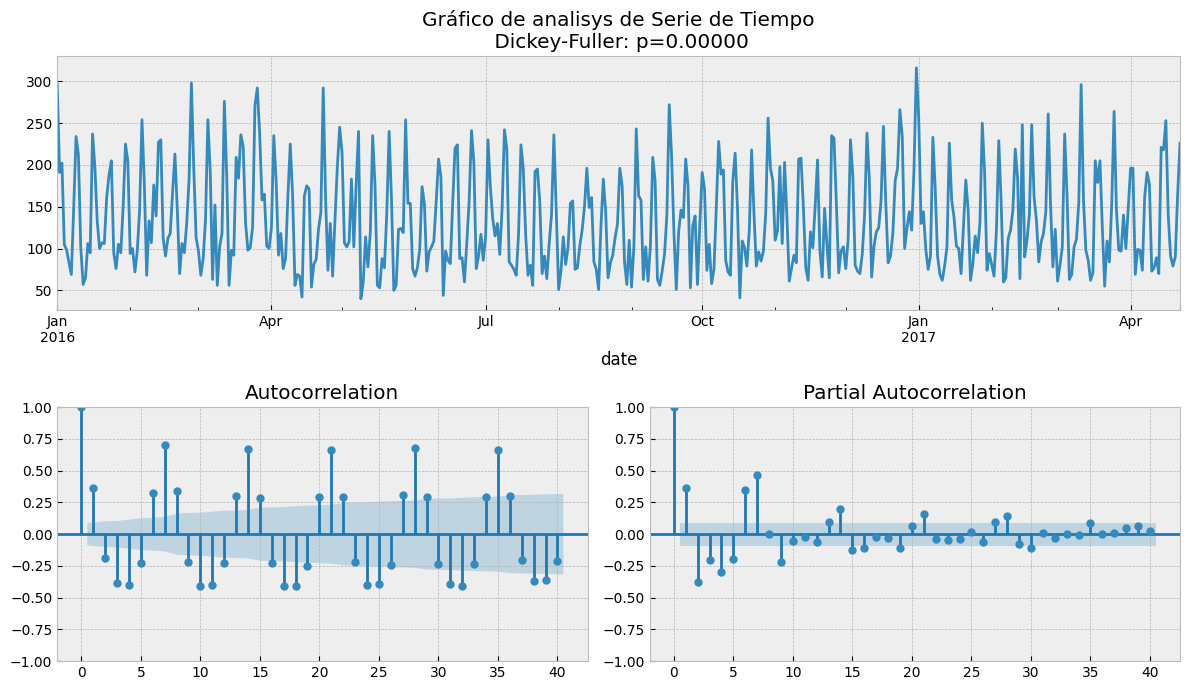

In [ ]:
tsplot(df1['total'], lags = 40);

In [ ]:
#warnings.filterwarnings(action='ignore',message='')
auto_arima(df1['total'], start_p = 1, start_q = 1, test='adf',

                         seasonal = True, m = 7,
                         trace = True,
                      error_action = 'ignore',
                      suppress_warnings = True,
                      stepwise = True)

Performing stepwise search to minimize aic
 ARIMA(1,0,1)(1,0,1)[7] intercept   : AIC=inf, Time=2.00 sec
 ARIMA(0,0,0)(0,0,0)[7] intercept   : AIC=5269.484, Time=0.03 sec
 ARIMA(1,0,0)(1,0,0)[7] intercept   : AIC=4916.749, Time=0.78 sec
 ARIMA(0,0,1)(0,0,1)[7] intercept   : AIC=5049.644, Time=0.55 sec
 ARIMA(0,0,0)(0,0,0)[7]             : AIC=6126.084, Time=0.02 sec
 ARIMA(1,0,0)(0,0,0)[7] intercept   : AIC=5200.790, Time=0.13 sec
 ARIMA(1,0,0)(2,0,0)[7] intercept   : AIC=4845.442, Time=2.16 sec
 ARIMA(1,0,0)(2,0,1)[7] intercept   : AIC=5343.249, Time=2.35 sec
 ARIMA(1,0,0)(1,0,1)[7] intercept   : AIC=4813.744, Time=1.89 sec
 ARIMA(1,0,0)(0,0,1)[7] intercept   : AIC=5058.642, Time=2.14 sec
 ARIMA(1,0,0)(1,0,2)[7] intercept   : AIC=4930.142, Time=3.57 sec
 ARIMA(1,0,0)(0,0,2)[7] intercept   : AIC=4982.776, Time=1.39 sec
 ARIMA(1,0,0)(2,0,2)[7] intercept   : AIC=inf, Time=3.75 sec
 ARIMA(0,0,0)(1,0,1)[7] intercept   : AIC=4771.197, Time=1.24 sec
 ARIMA(0,0,0)(0,0,1)[7] intercept   : AIC=5

ARIMA(order=(0, 0, 0), scoring_args={}, seasonal_order=(1, 0, 1, 7),
      suppress_warnings=True)

In [ ]:
len(df1)

478

Dividimos datos en entrenamiento y testeo

In [ ]:
train = df1.iloc[:436]
test = df1.iloc[436:] # ultimos 42 dias para evaluar

train.shape, test.shape

((436, 9), (42, 9))

In [ ]:
print(train)

              weekday  holiday    holiday_name  rest1  rest2  rest3  rest4  \
date                                                                         
2016-01-01     Friday        1  New Year's Day     65     25     67    139   
2016-01-02   Saturday        0              na     24     39     43     85   
2016-01-03     Sunday        0              na     24     31     66     81   
2016-01-04     Monday        0              na     23     18     32     32   
2016-01-05    Tuesday        0              na      2     15     38     43   
...               ...      ...             ...    ...    ...    ...    ...   
2017-03-07    Tuesday        0              na     28      9     19     13   
2017-03-08  Wednesday        0              na     27     19     35     21   
2017-03-09   Thursday        0              na     63     22     13     13   
2017-03-10     Friday        0              na     38     53     32     32   
2017-03-11   Saturday        0              na    128     29    

In [ ]:
print(test)

              weekday  holiday       holiday_name  rest1  rest2  rest3  rest4  \
date                                                                            
2017-03-12     Sunday        0                 na     46     16     55     41   
2017-03-13     Monday        0                 na     43     24     18     13   
2017-03-14    Tuesday        0                 na     21     14     22     29   
2017-03-15  Wednesday        0                 na     12     18     21     11   
2017-03-16   Thursday        0                 na     30      8     24      9   
2017-03-17     Friday        1  St. Patrick's Day     73     45     37     50   
2017-03-18   Saturday        0                 na     71     34     30     44   
2017-03-19     Sunday        0                 na     33     25     68     79   
2017-03-20     Monday        0                 na     34     22     19     50   
2017-03-21    Tuesday        0                 na      4     18     15     18   
2017-03-22  Wednesday       

## Ejecutamos los modelos

## Modelo 1 SARIMA

In [ ]:
model1 = SARIMAX(train['total'],order=(0,0,0),seasonal_order=(1,0,1,7), enforce_invertibility=False)


resultado1 = model1.fit()


resultado1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 SARIMAX Results                                 
=================================================================================
Dep. Variable:                     total   No. Observations:                  436
Model:             SARIMAX(1, 0, [1], 7)   Log Likelihood               -2165.369
Date:                   Thu, 23 Jul 2026   AIC                           4336.738
Time:                           00:19:42   BIC                           4348.970
Sample:                       01-01-2016   HQIC                          4341.565
                            - 03-11-2017                                         
Covariance Type:                     opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.S.L7        0.9999   9.57e-05   1.04e+04      0.000       1.000       1.000
ma.S.L7       -0.9384      0.024    -39.206      0.000      -0.985      -0.891
sigma2      1111.7995     58.740     18.927      0.000     996.671    1226.928
===================================================================================
Ljung-Box (L1) (Q):                  15.40   Jarque-Bera (JB):                83.57
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               0.96   Skew:                             0.72
Prob(H) (two-sided):                  0.81   Kurtosis:                         4.59
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Analizamos los residuos del modelo

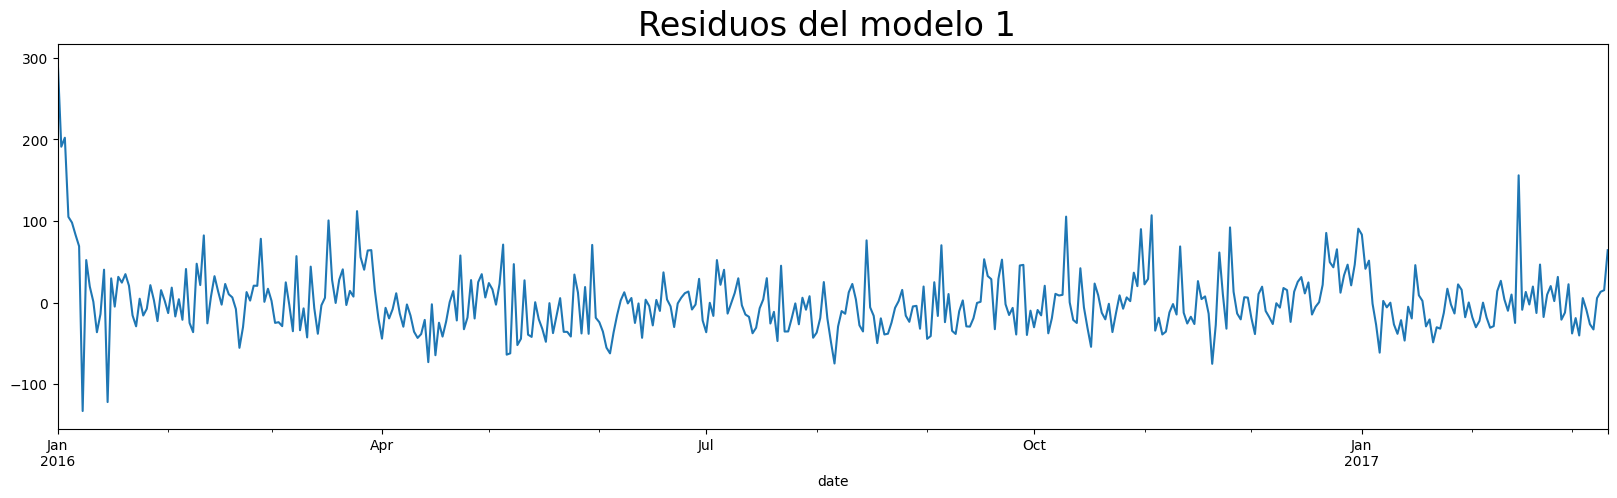

In [ ]:
resultado1.resid.plot(figsize=(20,5))
plt.title("Residuos del modelo 1 ",size=24)
plt.show()

Aca vemos patrones de autocorrelacion q muestra q el modelo no capta la dinamica no estacional de la serie. Los residuos presentan picos y valles repetitivos en el tiempo esto va en contra de la hipótesis de ruido blanco necesaria para validar el modelo. Esto sugiere la presencia de estructura AR de corto plazo no modelada.

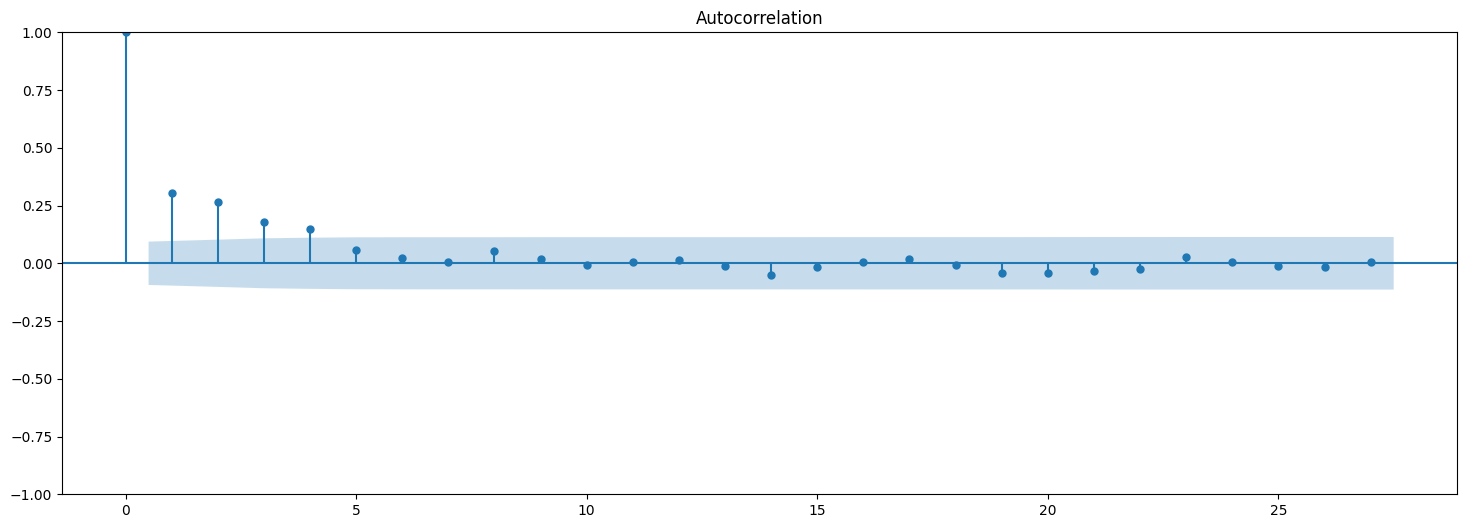

In [ ]:
plot_acf(resultado1.resid);

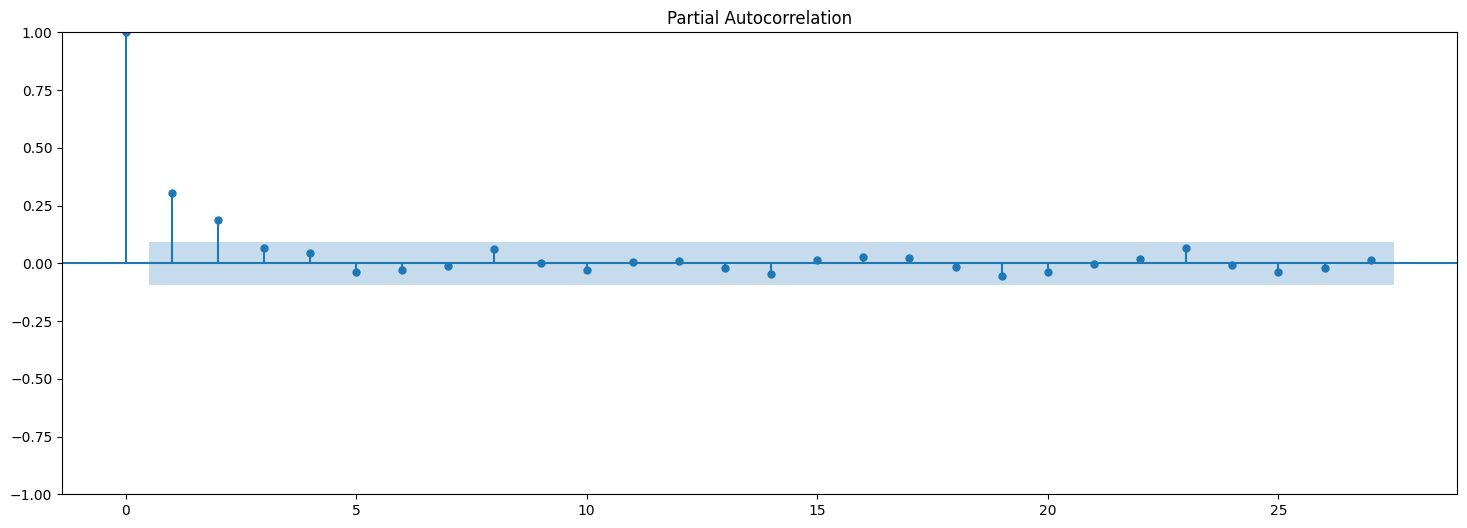

In [ ]:
plot_pacf(resultado1.resid);

In [ ]:
import statsmodels.api as sm

In [ ]:
Incorr_residuos_modelo=sm.stats.acorr_ljungbox(resultado1.resid, lags=30)
Incorr_residuos_modelo

,lb_stat,lb_pvalue
1,41.074357,1.465465e-10
2,71.710840,2.680334e-16
3,86.133490,1.481950e-18
4,95.732911,7.959270e-20
5,97.275437,1.981775e-19
6,97.549789,8.137637e-19
7,97.571874,3.420249e-18
8,98.903182,7.152182e-18
9,99.051237,2.447385e-17
10,99.067997,8.371972e-17


Text(0, 0.5, 'P-valores ')

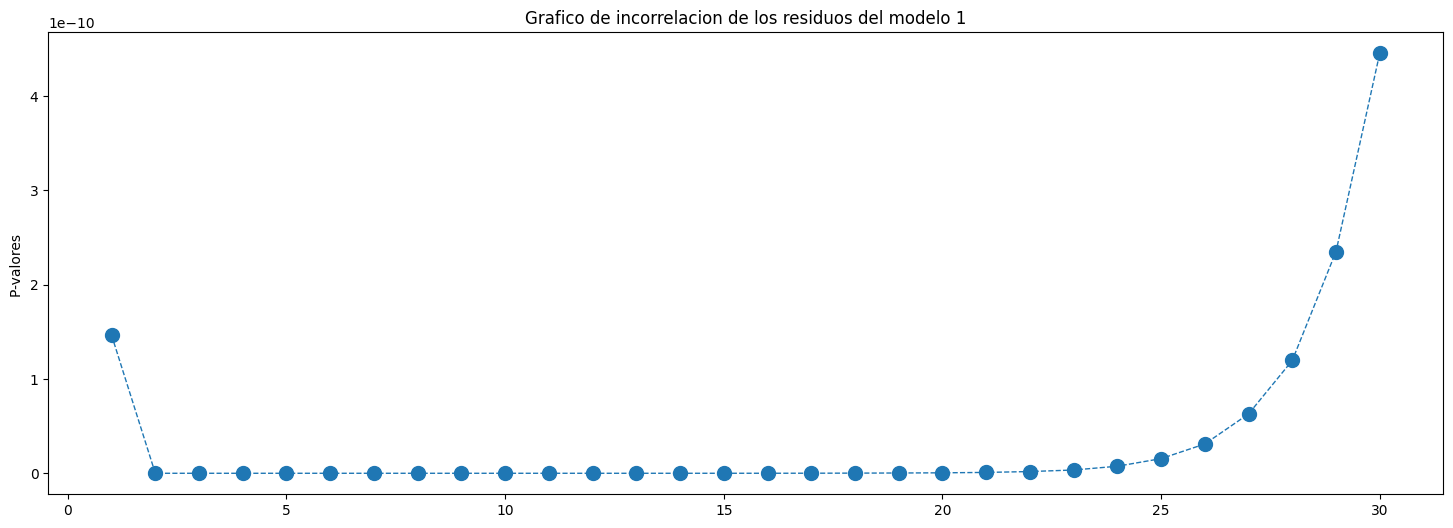

In [ ]:
plt.plot(Incorr_residuos_modelo.lb_pvalue, marker='o', markersize=10, linestyle='--', linewidth=1)
plt.title("Grafico de incorrelacion de los residuos del modelo 1")
plt.ylabel("P-valores ")

In [ ]:
end = len(train) + len(test) - 1
end

477

In [ ]:
start = len(train)
end = len(train) + len(test) - 1
pred1 = resultado1.predict(start = start,end = end,dynamic = False).rename('SARIMA(0,0,0)(1,0,[1],7) Predicciones')
pred1

,"SARIMA(0,0,0)(1,0,[1],7) Predicciones"
2017-03-12,172.107119
2017-03-13,87.862076
2017-03-14,99.905174
2017-03-15,96.839854
2017-03-16,98.639336
2017-03-17,140.730110
2017-03-18,235.746066
2017-03-19,172.089749
2017-03-20,87.853209
2017-03-21,99.895091


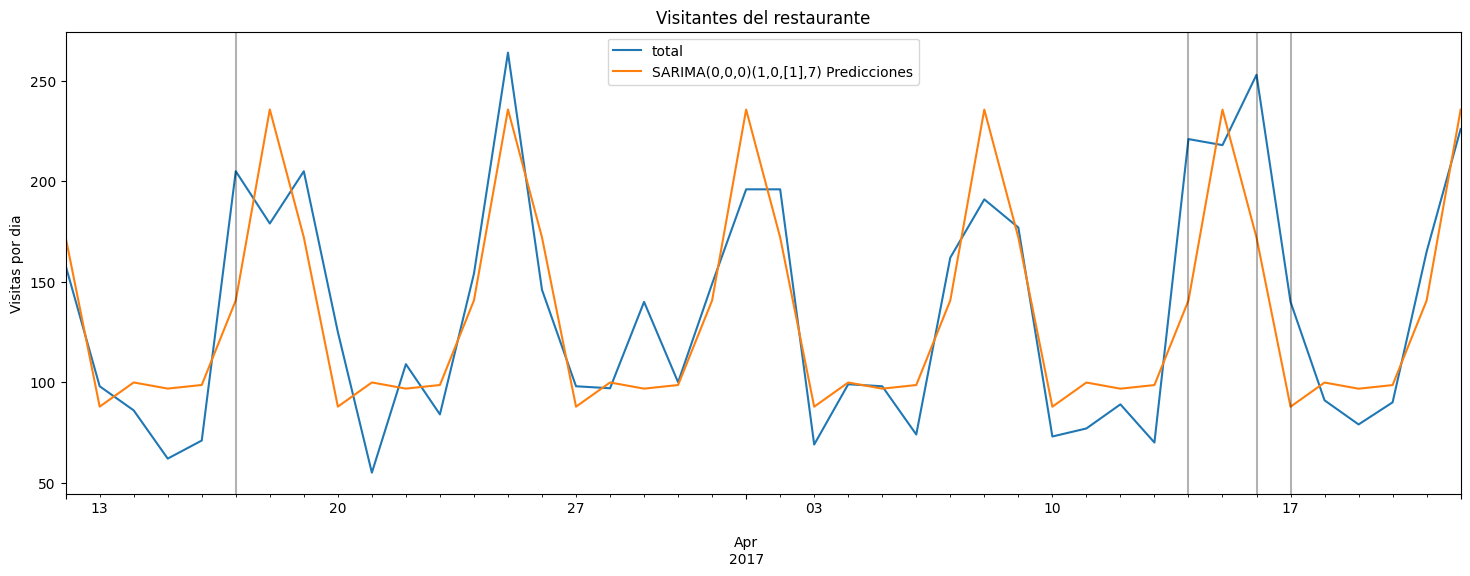

In [ ]:
title = 'Visitantes del restaurante'
ylabel = 'Visitas por dia'
xlabel = ''

ax = test['total'].plot(legend=True,title=title)
pred1.plot(legend=True)
ax.autoscale(axis='x',tight=True)
ax.set(xlabel=xlabel,ylabel=ylabel)
for x in test[test['holiday']==1].index:
    ax.axvline(x=x,color='k',alpha=0.3)

Realizamos las metricas del modelo

In [ ]:
from statsmodels.tools.eval_measures import mse,rmse


In [ ]:
mse_error_1 = mse(test['total'],pred1)
rmse_error_1 = rmse(test['total'],pred1)

In [ ]:
print(f'SARIMA(0,0,0)(1,0,[1],7) MSE Error: {mse_error_1:11.10}')
print(f'SARIMA(0,0,0)(0,0,[1],7) RMSE Error: {rmse_error_1:11.10}')

SARIMA(0,0,0)(1,0,[1],7) MSE Error: 1018.413679
SARIMA(0,0,0)(0,0,[1],7) RMSE Error: 31.91259437


In [ ]:
train

,weekday,holiday,holiday_name,rest1,rest2,rest3,rest4,total,mean
date,,,,,,,,,
2016-01-01,Friday,1,New Year's Day,65,25,67,139,296,74.00
2016-01-02,Saturday,0,na,24,39,43,85,191,47.75
2016-01-03,Sunday,0,na,24,31,66,81,202,50.50
2016-01-04,Monday,0,na,23,18,32,32,105,26.25
2016-01-05,Tuesday,0,na,2,15,38,43,98,24.50
...,...,...,...,...,...,...,...,...,...
2017-03-07,Tuesday,0,na,28,9,19,13,69,17.25
2017-03-08,Wednesday,0,na,27,19,35,21,102,25.50
2017-03-09,Thursday,0,na,63,22,13,13,111,27.75


In [ ]:
auto_arima(
    df1['total'],
    start_p=0, start_q=0,
    max_p=4, max_q=4,
    start_P=0, start_Q=0,
    max_P=2, max_Q=2,
    seasonal=True, m=7,
    d=None, D=None,
    test='adf',
    seasonal_test='ocsb',
    trace=True,
    stepwise=False,
    approximation=False,
    suppress_warnings=True
)

 ARIMA(0,0,0)(0,0,0)[7] intercept   : AIC=5269.484, Time=0.03 sec
 ARIMA(0,0,0)(0,0,1)[7] intercept   : AIC=5093.130, Time=0.24 sec
 ARIMA(0,0,0)(0,0,2)[7] intercept   : AIC=5010.582, Time=1.05 sec
 ARIMA(0,0,0)(1,0,0)[7] intercept   : AIC=4926.360, Time=0.54 sec
 ARIMA(0,0,0)(1,0,1)[7] intercept   : AIC=4771.197, Time=1.24 sec
 ARIMA(0,0,0)(1,0,2)[7] intercept   : AIC=4892.998, Time=2.25 sec
 ARIMA(0,0,0)(2,0,0)[7] intercept   : AIC=4859.638, Time=4.38 sec
 ARIMA(0,0,0)(2,0,1)[7] intercept   : AIC=4970.972, Time=3.30 sec
 ARIMA(0,0,0)(2,0,2)[7] intercept   : AIC=inf, Time=2.96 sec
 ARIMA(0,0,1)(0,0,0)[7] intercept   : AIC=5162.629, Time=0.26 sec
 ARIMA(0,0,1)(0,0,1)[7] intercept   : AIC=5049.644, Time=0.54 sec
 ARIMA(0,0,1)(0,0,2)[7] intercept   : AIC=4979.208, Time=1.23 sec
 ARIMA(0,0,1)(1,0,0)[7] intercept   : AIC=4917.813, Time=0.66 sec
 ARIMA(0,0,1)(1,0,1)[7] intercept   : AIC=inf, Time=1.55 sec
 ARIMA(0,0,1)(1,0,2)[7] intercept   : AIC=4862.244, Time=4.62 sec
 ARIMA(0,0,1)(2,0,0)

/usr/local/lib/python3.12/dist-packages/pmdarima/arima/_auto_solvers.py:524: ModelFitWarning: Error fitting  ARIMA(2,0,0)(1,0,2)[7] intercept (if you do not want to see these warnings, run with error_action="ignore").
Traceback:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pmdarima/arima/_auto_solvers.py", line 508, in _fit_candidate_model
    fit.fit(y, X=X, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/pmdarima/arima/arima.py", line 603, in fit
    self._fit(y, X, **fit_args)
  File "/usr/local/lib/python3.12/dist-packages/pmdarima/arima/arima.py", line 524, in _fit
    fit, self.arima_res_ = _fit_wrapper()
                           ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pmdarima/arima/arima.py", line 510, in _fit_wrapper
    fitted = arima.fit(
             ^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py", line 705, in fit
    mlefit = super().fit(start_pa

 ARIMA(2,0,0)(1,0,2)[7] intercept   : AIC=inf, Time=nan sec
 ARIMA(2,0,0)(2,0,0)[7] intercept   : AIC=4845.525, Time=3.42 sec
 ARIMA(2,0,0)(2,0,1)[7] intercept   : AIC=4956.857, Time=5.95 sec
 ARIMA(2,0,1)(0,0,0)[7] intercept   : AIC=5091.644, Time=0.78 sec
 ARIMA(2,0,1)(0,0,1)[7] intercept   : AIC=5014.138, Time=1.62 sec
 ARIMA(2,0,1)(0,0,2)[7] intercept   : AIC=4983.228, Time=1.28 sec
 ARIMA(2,0,1)(1,0,0)[7] intercept   : AIC=inf, Time=1.81 sec
 ARIMA(2,0,1)(1,0,1)[7] intercept   : AIC=4977.657, Time=3.44 sec
 ARIMA(2,0,1)(2,0,0)[7] intercept   : AIC=inf, Time=4.13 sec
 ARIMA(2,0,2)(0,0,0)[7] intercept   : AIC=5153.349, Time=0.63 sec
 ARIMA(2,0,2)(0,0,1)[7] intercept   : AIC=5049.597, Time=1.94 sec
 ARIMA(2,0,2)(1,0,0)[7] intercept   : AIC=4914.129, Time=1.99 sec
 ARIMA(2,0,3)(0,0,0)[7] intercept   : AIC=inf, Time=1.16 sec
 ARIMA(3,0,0)(0,0,0)[7] intercept   : AIC=5110.234, Time=0.43 sec
 ARIMA(3,0,0)(0,0,1)[7] intercept   : AIC=5023.635, Time=0.59 sec
 ARIMA(3,0,0)(0,0,2)[7] interce

ARIMA(order=(0, 0, 0), scoring_args={}, seasonal_order=(1, 0, 1, 7),
      suppress_warnings=True)

## MODELO 2 SARIMA

In [ ]:
modelo2 = SARIMAX(
    train['total'],
    order=(2,0,0),
    seasonal_order=(1,0,1,7),
    enforce_stationarity=False,
    enforce_invertibility=False)


resultado2 = modelo2.fit()


resultado2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                               total   No. Observations:                  436
Model:             SARIMAX(2, 0, 0)x(1, 0, [1], 7)   Log Likelihood               -2086.760
Date:                             Thu, 23 Jul 2026   AIC                           4183.520
Time:                                     00:24:21   BIC                           4203.804
Sample:                                 01-01-2016   HQIC                          4191.532
                                      - 03-11-2017                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1883      0.047      4.008      0.000       0.096       0.280
ar.L2          0.1265      0.052      2.430      0.015       0.024       0.228
ar.S.L7        0.9991      0.001    839.628      0.000       0.997       1.001
ma.S.L7       -0.9536      0.024    -40.219      0.000      -1.000      -0.907
sigma2       989.1980     51.155     19.337      0.000     888.936    1089.460
===================================================================================
Ljung-Box (L1) (Q):                   0.04   Jarque-Bera (JB):               136.32
Prob(Q):                              0.83   Prob(JB):                         0.00
Heteroskedasticity (H):               1.05   Skew:                             0.94
Prob(H) (two-sided):                  0.76   Kurtosis:                         5.04
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

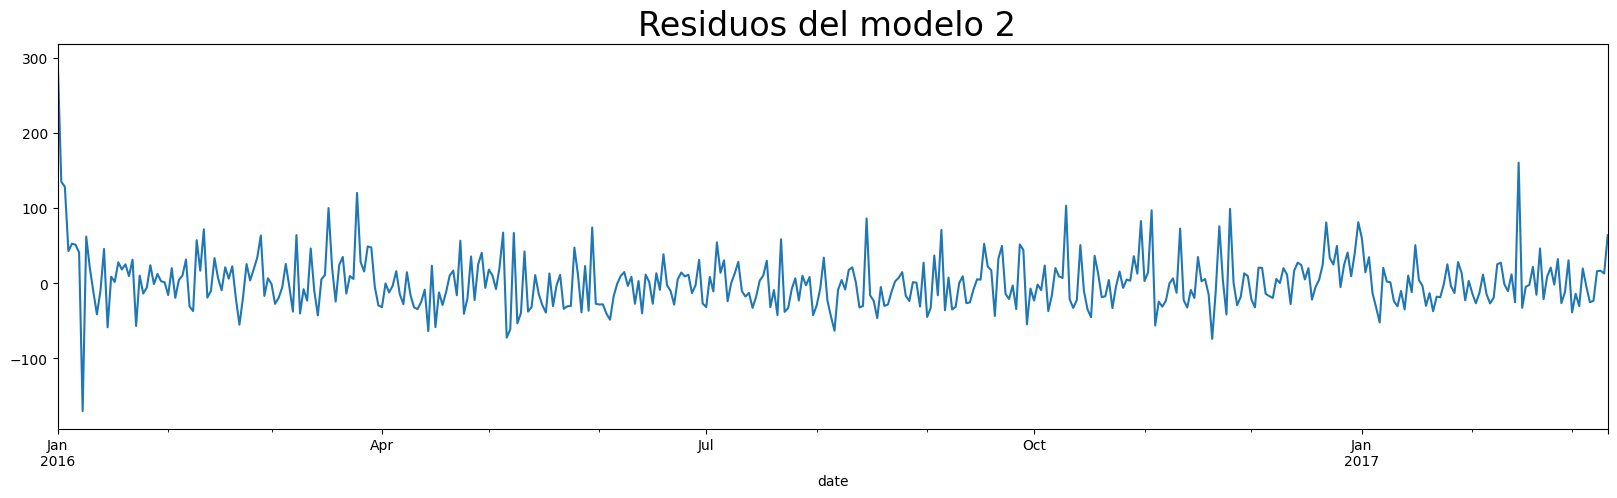

In [ ]:
resultado2.resid.plot(figsize=(20,5))
plt.title("Residuos del modelo 2 ",size=24)
plt.show()


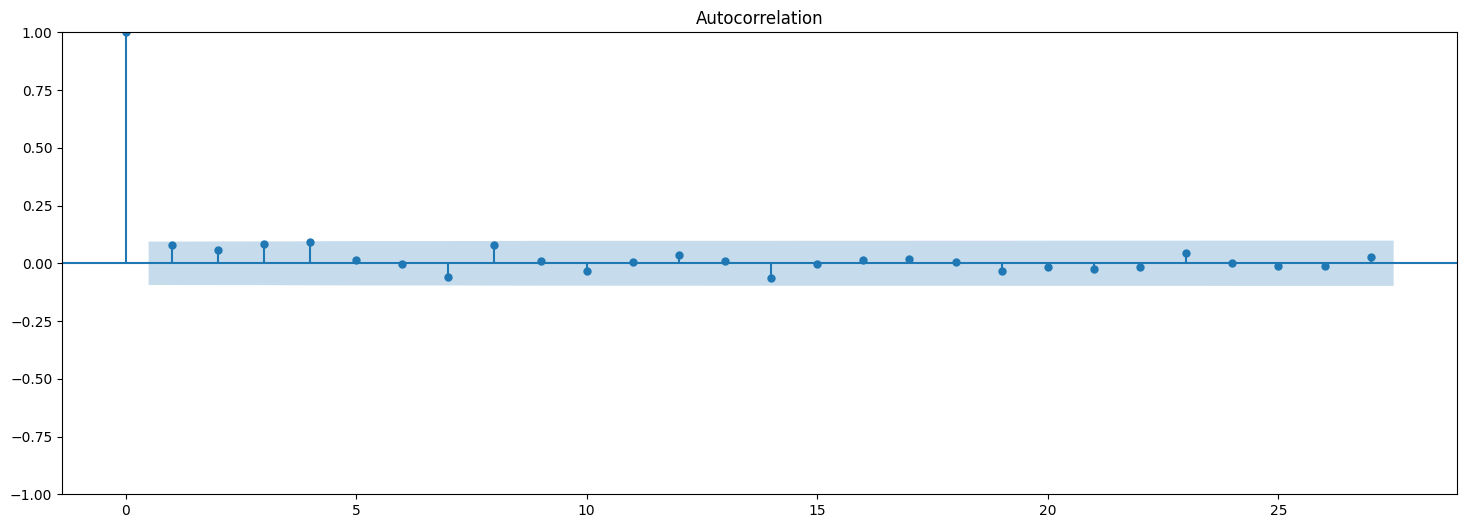

In [ ]:
plot_acf(resultado2.resid);


In [ ]:
import statsmodels.api as sm


Incorr_residuos_modelo2=sm.stats.acorr_ljungbox(resultado2.resid, lags=30)
Incorr_residuos_modelo2

,lb_stat,lb_pvalue
1,2.715560,0.099374
2,4.190959,0.123011
3,7.184500,0.066244
4,10.981047,0.026778
5,11.046124,0.050473
6,11.055708,0.086670
7,12.525568,0.084547
8,15.381378,0.052140
9,15.409455,0.080286
10,15.878143,0.103174


Text(0, 0.5, 'P-valores ')

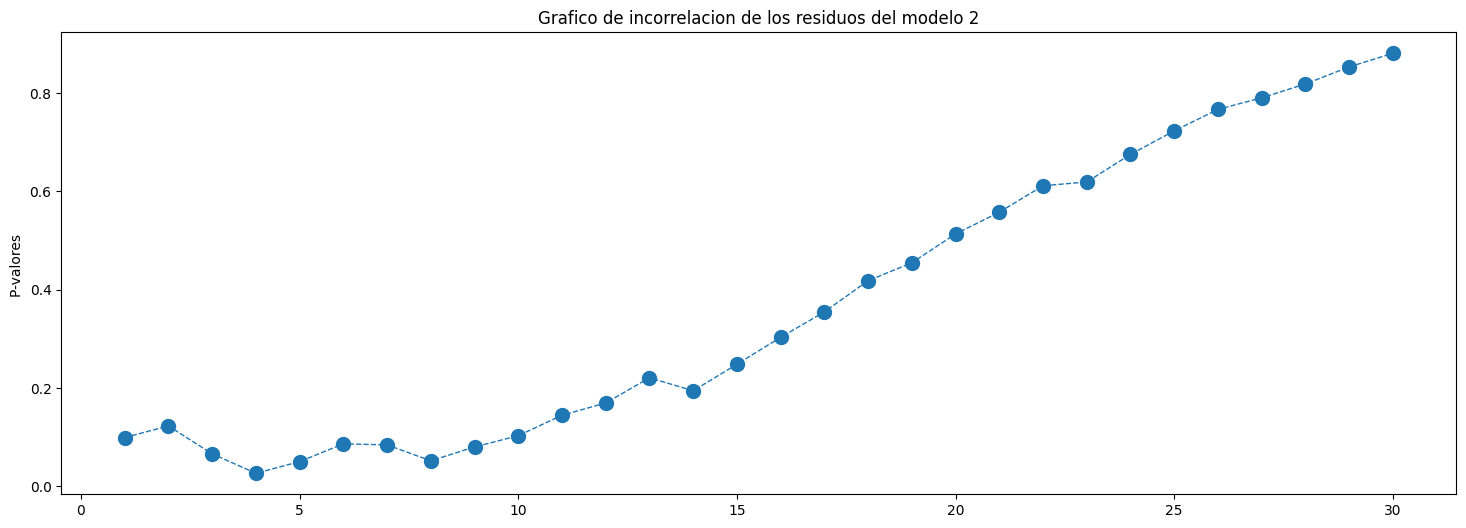

In [ ]:
plt.plot(Incorr_residuos_modelo2.lb_pvalue, marker='o', markersize=10, linestyle='--', linewidth=1)
plt.title("Grafico de incorrelacion de los residuos del modelo 2")
plt.ylabel("P-valores ")

In [ ]:
end = len(train) + len(test) - 1
end



477

In [ ]:
start = len(train)
end = len(train) + len(test) - 1
pred2 = resultado2.predict(start = start,end = end,dynamic = False).rename('SARIMA(2, 0, 0)x(1, 0, [1], 7) Predictions')
pred2

,"SARIMA(2, 0, 0)x(1, 0, [1], 7) Predictions"
2017-03-12,185.920841
2017-03-13,98.643975
2017-03-14,100.730845
2017-03-15,97.076605
2017-03-16,98.101971
2017-03-17,139.482190
2017-03-18,230.242626
2017-03-19,171.476901
2017-03-20,87.585255
2017-03-21,96.769574


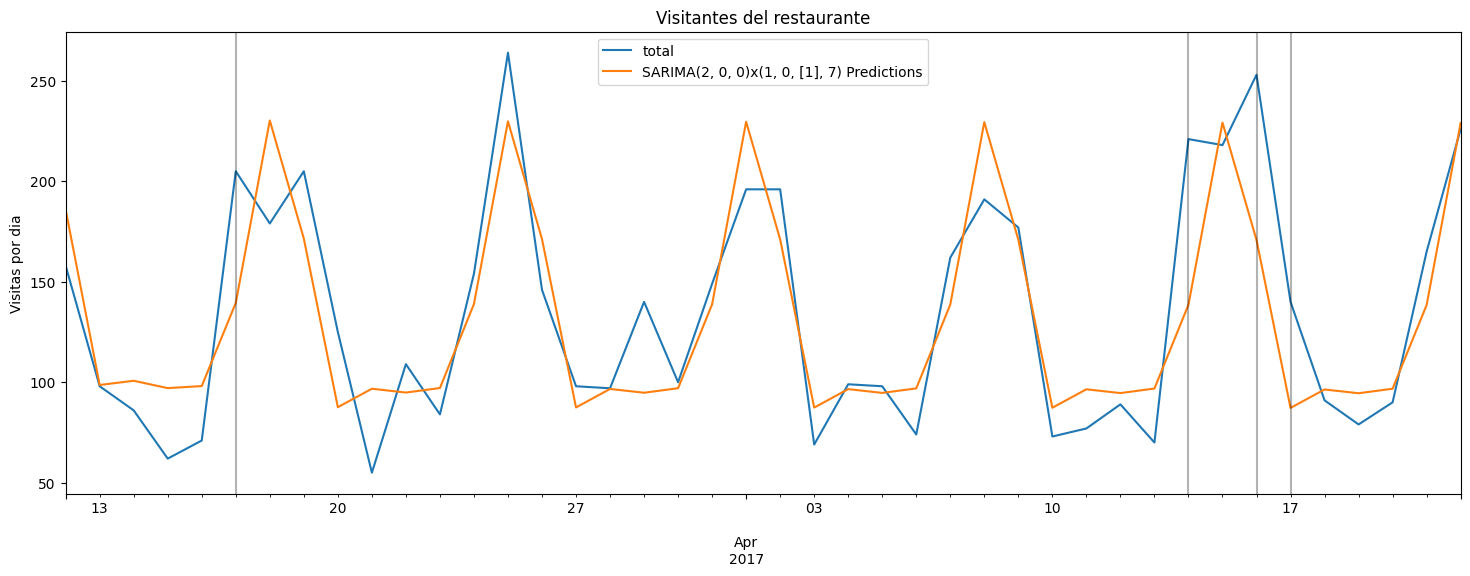

In [ ]:
title = 'Visitantes del restaurante'
ylabel = 'Visitas por dia'
xlabel = ''

ax = test['total'].plot(legend=True,title=title)
pred2.plot(legend=True)
ax.autoscale(axis='x',tight=True)
ax.set(xlabel=xlabel,ylabel=ylabel)
for x in test[test['holiday']==1].index:
    ax.axvline(x=x,color='k',alpha=0.3)

In [ ]:
from statsmodels.tools.eval_measures import mse,rmse


mse_error_2 = mse(test['total'],pred2)
rmse_error_2 = rmse(test['total'],pred2)


print(f'SARIMA(2, 0, 0)x(1, 0, [1], 7) MSE Error: {mse_error_2:11.10}')
print(f'SARIMA(2, 0, 0)x(1, 0, [1], 7) RMSE Error: {rmse_error_2:11.10}')


SARIMA(2, 0, 0)x(1, 0, [1], 7) MSE Error: 1008.354579
SARIMA(2, 0, 0)x(1, 0, [1], 7) RMSE Error: 31.75459934


## Modelo 3 - Con valores exogenos

In [ ]:
model3 = SARIMAX(train['total'],exog = train[['holiday']],order = (2,0,0),seasonal_order = (1,0,[1],7),enforce_invertibility = False)
resultado3 = model3.fit()
resultado3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                               total   No. Observations:                  436
Model:             SARIMAX(2, 0, 0)x(1, 0, [1], 7)   Log Likelihood               -2088.666
Date:                             Thu, 23 Jul 2026   AIC                           4189.332
Time:                                     00:24:42   BIC                           4213.798
Sample:                                 01-01-2016   HQIC                          4198.987
                                      - 03-11-2017                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
holiday       67.2455      3.998     16.820      0.000      59.410      75.081
ar.L1          0.2033      0.047      4.368      0.000       0.112       0.295
ar.L2          0.0454      0.052      0.873      0.383      -0.057       0.147
ar.S.L7        0.9999   9.11e-05    1.1e+04      0.000       1.000       1.000
ma.S.L7       -1.0554      0.025    -41.586      0.000      -1.105      -1.006
sigma2       702.4814     48.149     14.590      0.000     608.112     796.851
===================================================================================
Ljung-Box (L1) (Q):                   0.10   Jarque-Bera (JB):                20.37
Prob(Q):                              0.75   Prob(JB):                         0.00
Heteroskedasticity (H):               0.98   Skew:                             0.23
Prob(H) (two-sided):                  0.89   Kurtosis:                         3.95
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [ ]:
start = len(train)
end = len(train)+len(test)-1
exog_forecast = test[['holiday']]
pred3 =  resultado3.predict(start =start,end=end,exog=exog_forecast).rename('SARIMAX(2,0,0)(1,0,[1],7) Predictions')
pred3

,"SARIMAX(2,0,0)(1,0,[1],7) Predictions"
2017-03-12,182.059750
2017-03-13,83.540595
2017-03-14,97.543568
2017-03-15,97.283876
2017-03-16,93.944113
2017-03-17,205.170834
2017-03-18,230.370324
2017-03-19,167.930102
2017-03-20,77.685384
2017-03-21,95.705169


In [ ]:
test[['holiday']][:10]

,holiday
date,
2017-03-12,0
2017-03-13,0
2017-03-14,0
2017-03-15,0
2017-03-16,0
2017-03-17,1
2017-03-18,0
2017-03-19,0
2017-03-20,0


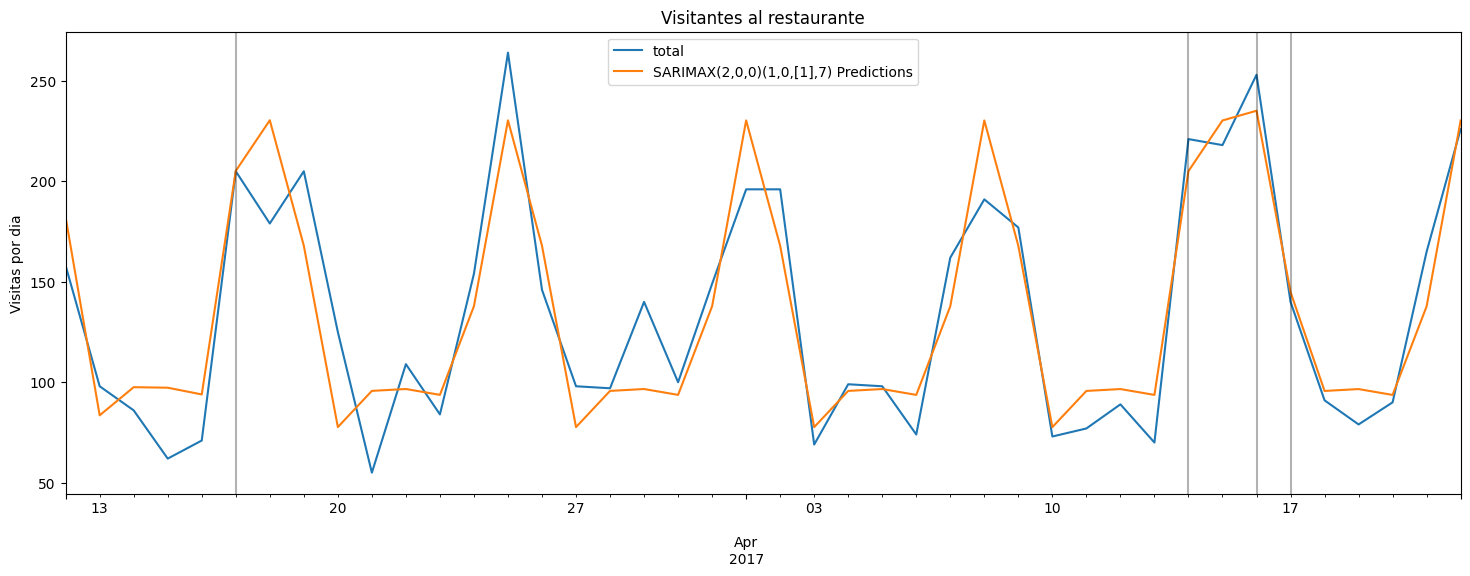

In [ ]:
title = 'Visitantes al restaurante'
ylabel = 'Visitas por dia'
xlabel = ''

ax = test['total'].plot(legend=True,title=title)
pred3.plot(legend=True)
ax.autoscale(axis='x',tight=True)
ax.set(xlabel=xlabel,ylabel=ylabel)
for x in test[test['holiday']==1].index:
    ax.axvline(x=x,color='k',alpha=0.3)

In [ ]:
# Print values from SARIMA above
#print(f'SARIMA(2,0,0)(2,0,0,7) MSE Error: {mse_error:11.10}')
#print(f'SARIMA(2,0,0)(2,0,0,7) RMSE Error: {rmse_error:11.10}')
#print()

mse_error_3 = mse(test['total'], pred3)
rmse_error_3 = rmse(test['total'], pred3)

# SARIMAX con Exogenas
print("Con Exogenas")
print(f'SARIMAX(2,0,0)(2,0,0,7) MSE Error: {mse_error_3:11.10}')
print(f'SARIMAX(2,0,0)(2,0,0,7) RMSE Error: {rmse_error_3:11.10}')

Con Exogenas
SARIMAX(2,0,0)(2,0,0,7) MSE Error: 540.0264777
SARIMAX(2,0,0)(2,0,0,7) RMSE Error: 23.23846978


In [ ]:
train

,weekday,holiday,holiday_name,rest1,rest2,rest3,rest4,total,mean
date,,,,,,,,,
2016-01-01,Friday,1,New Year's Day,65,25,67,139,296,74.00
2016-01-02,Saturday,0,na,24,39,43,85,191,47.75
2016-01-03,Sunday,0,na,24,31,66,81,202,50.50
2016-01-04,Monday,0,na,23,18,32,32,105,26.25
2016-01-05,Tuesday,0,na,2,15,38,43,98,24.50
...,...,...,...,...,...,...,...,...,...
2017-03-07,Tuesday,0,na,28,9,19,13,69,17.25
2017-03-08,Wednesday,0,na,27,19,35,21,102,25.50
2017-03-09,Thursday,0,na,63,22,13,13,111,27.75


Agrego mas variables exogenas

In [ ]:
model4 = SARIMAX(train['total'],exog = train[['holiday', "rest1"]],order=(2,0,0),seasonal_order=(1,0,[1],7),enforce_invertibility=False)
resultado4 = model4.fit()
resultado4.summary()

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                               total   No. Observations:                  436
Model:             SARIMAX(2, 0, 0)x(1, 0, [1], 7)   Log Likelihood               -1996.148
Date:                             Thu, 23 Jul 2026   AIC                           4006.296
Time:                                     00:34:04   BIC                           4034.840
Sample:                                 01-01-2016   HQIC                          4017.561
                                      - 03-11-2017                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
holiday       50.4335      2.861     17.631      0.000      44.827      56.040
rest1          1.1278      0.065     17.311      0.000       1.000       1.256
ar.L1          0.2157      0.045      4.842      0.000       0.128       0.303
ar.L2          0.1545      0.050      3.098      0.002       0.057       0.252
ar.S.L7        0.9997      0.000   4269.373      0.000       0.999       1.000
ma.S.L7       -0.9299      0.024    -39.147      0.000      -0.977      -0.883
sigma2       518.6319     30.015     17.279      0.000     459.803     577.460
===================================================================================
Ljung-Box (L1) (Q):                   0.39   Jarque-Bera (JB):                20.85
Prob(Q):                              0.53   Prob(JB):                         0.00
Heteroskedasticity (H):               0.88   Skew:                             0.19
Prob(H) (two-sided):                  0.43   Kurtosis:                         4.00
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [ ]:

start = len(train)
end = len(train)+len(test)-1
exog_forecast = test[['holiday', "rest1"]]
pred4 =  resultado4.predict(start =start,end=end,exog=exog_forecast).rename('SARIMAX(2,0,0)(1,0,[1],7) X2')
pred4

,"SARIMAX(2,0,0)(1,0,[1],7) X2"
2017-03-12,180.631817
2017-03-13,101.912045
2017-03-14,91.712692
2017-03-15,80.860884
2017-03-16,91.274753
2017-03-17,223.499192
2017-03-18,222.623918
2017-03-19,160.677351
2017-03-20,89.214950
2017-03-21,71.161008


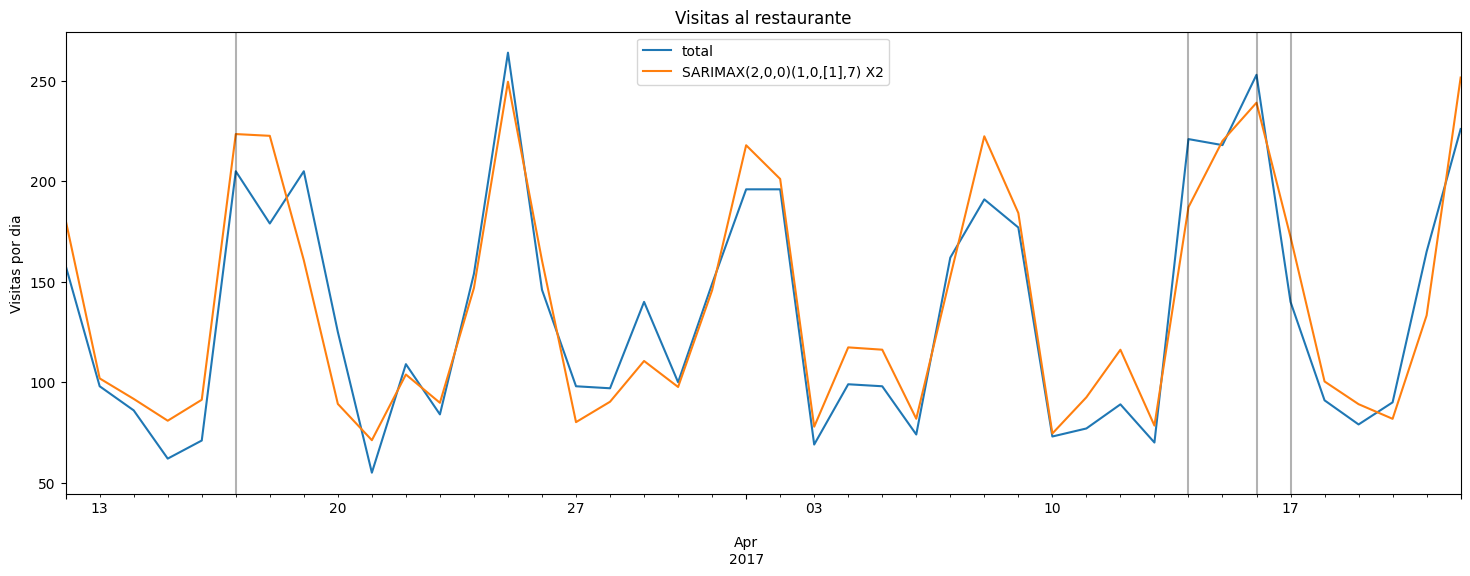

In [ ]:
title = 'Visitas al restaurante'
ylabel = 'Visitas por dia'
xlabel = ''

ax = test['total'].plot(legend=True,title=title)
pred4.plot(legend=True)
ax.autoscale(axis='x',tight=True)
ax.set(xlabel=xlabel,ylabel=ylabel)
for x in test[test['holiday']==1].index:
    ax.axvline(x=x,color='k',alpha=0.3)

In [ ]:
mse_error_4 = mse(test['total'], pred4)
rmse_error_4 = rmse(test['total'], pred4)

# SARIMAX con Exogenas
print("Con Exogenas")
print(f'SARIMAX(2,0,0)(2,0,0,7) MSE Error: {mse_error_4:11.10}')
print(f'SARIMAX(2,0,0)(2,0,0,7) RMSE Error: {rmse_error_4:11.10}')

Con Exogenas
SARIMAX(2,0,0)(2,0,0,7) MSE Error: 396.6595378
SARIMAX(2,0,0)(2,0,0,7) RMSE Error: 19.91631336


FIN DEL EJERCICIO